# Tutorial example

In this notebook, a simple example of comparison of Low-fidelity (LF), High-fidelity (HF) and Multi-fidelity (MF) networks is shown.

It is possible to notice that the interaction of LF and HF data and structures in a 2-step network can be benefical to build a performant regression model.

Here, 3 possible simple example can be created

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
import warnings
import keras
import sys
import os
import logging
from pathlib import Path

# Suppress DeprecationWarnings from TensorFlow
warnings.filterwarnings("ignore", category=DeprecationWarning, module="tensorflow")

# Set TensorFlow logging level to ERROR
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Append the utils directory to the system path
sys.path.append('../utils')

# Import necessary modules from utils
from Structure_new import *
from module_utils import *
from data_collection import *


# Load context functions
current_file_path = Path().resolve()  # Get the current notebook path
load_context_functions(current_file_path.parent.name)  # Load context functions using the parent folder name

 # Restore the output


# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)


## Presentation of the model 

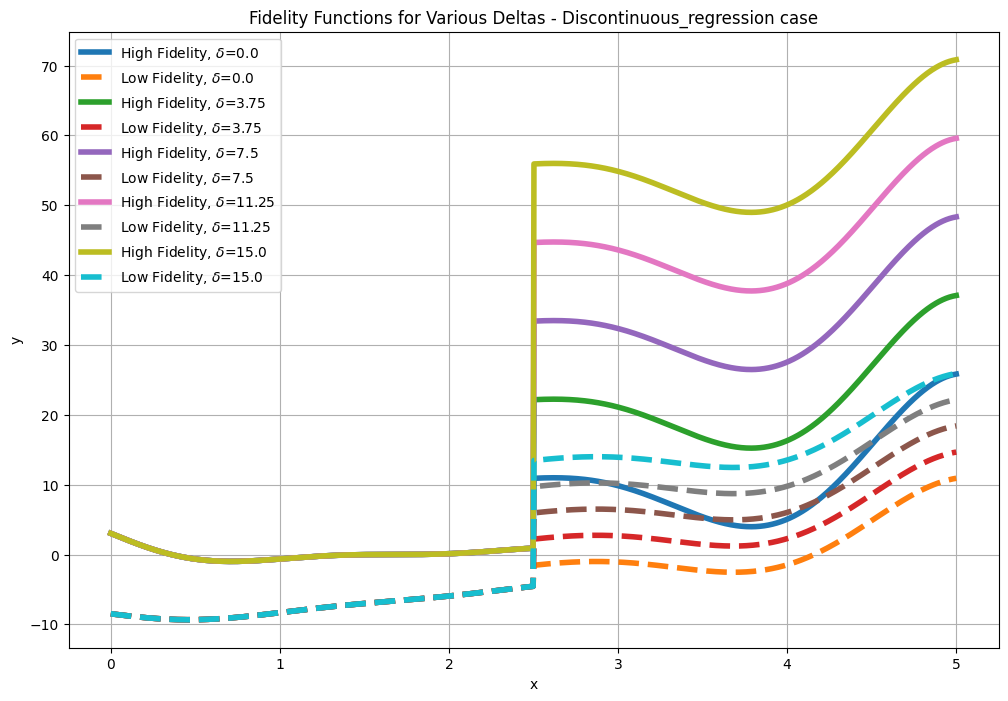

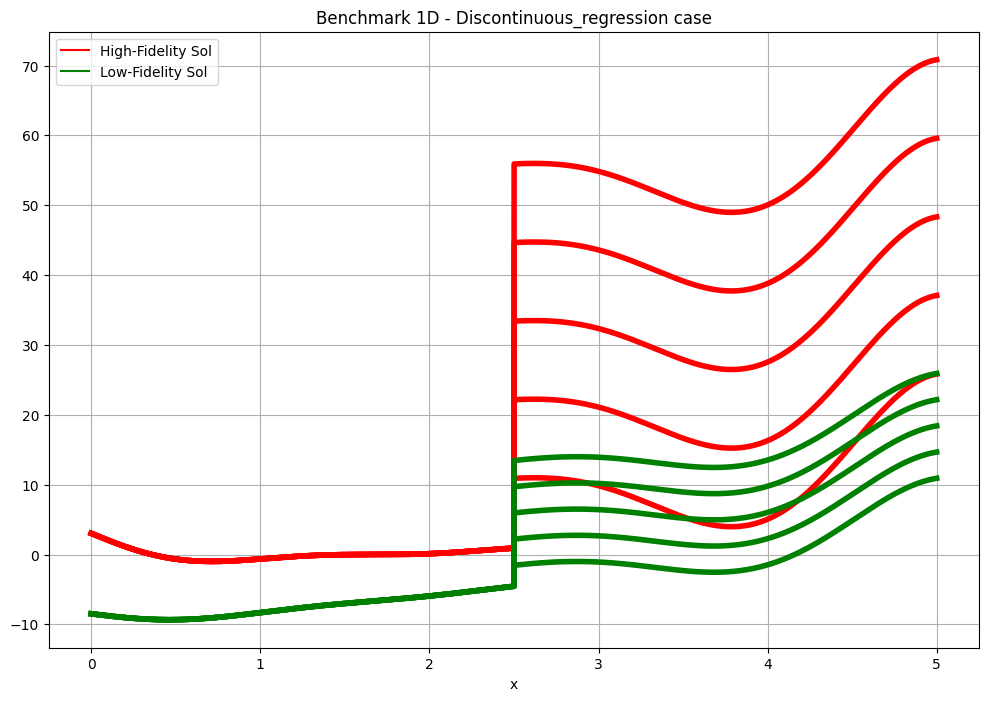

In [2]:
example ="Discontinuous_regression"                     # Here, the model can be chosen between "Basic_regression", "Discontinuous_regression" and "Oscillatory_regression". 
fidelity_func = FidelityFunctionModified(example)
# The plots show how the chosen function varies with respect to a parameter \delta and the comparison between "high-fidelity" (i.e. very precise) and "low-fidelity" data
fidelity_func.plot_functions()
fidelity_func.plot_detailed_functions()

# data are saved and taken from external file 
data=fidelity_func.get_parameters(example)  

## Low-fidelity Neural Network

Example of Neural network built on low fidelity data. It is possible to notice that the model is not well approximated in None of the 3 cases

The function training took 43.767213 seconds.


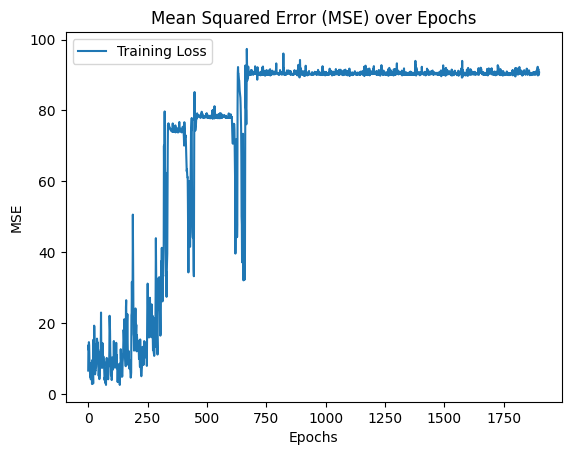

Test MSE: 696.2389288078592
R^2: -0.6444673443394515


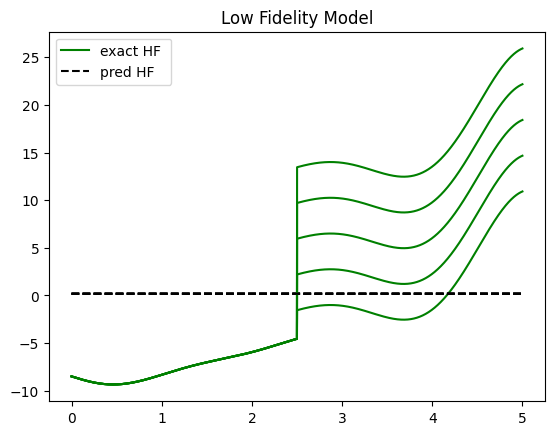

In [3]:
# parameters of the Neural Network
bestLF_params = {'lr' : 0.0255, 
                 'kernel_init' : 'glorot_uniform', 
                 'opt' : 'Adam'}

# inputs for the definition of a Single level Neural Network
definition_LF={
        "network_type": "LF",               
        "network_parameters": bestLF_params,    # parameters to define the network
        "dataset_train": data["xlf"],           # training set
        "output_train": data["Ylf"],            # output of the training set    
        "epochs_number": data["NepoLF"],        # Epochs
        "batch_size": data["Nlf"],              # batch size
        "train": True,                          # The NN is trained
        "do_HPO": False,                        # Do not Hyperparameter Optimization, please, notice that the process requires some time. 
                                                # If parameters with better estimated performance are found, they will substitute the actual parameters 
        "verbose": False                        # reduce printed unnecessary output
    }

# initialization of the neural network
config = NetworkConfig(**definition_LF)
modelLF=NetworkFactory.build_network(config)

# prediction step
yLF=modelLF.prediction(data["datatest"])
# performance measurement
(mse_LF,R2_LF)=modelLF.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))



# plot the real and estimated relation, it allows a qualitative and immediate comparison 
unique_values = np.unique(data["xlf"][:, 1])
plt.figure()
for val in unique_values:
    mask = data["datatest"][:, 1] == val
    x_values = data["datatest"][mask, 0]
    y_exact = data["modified_lowfid"](x_values, val)
    y_pred = yLF[mask]

    plt.plot(x_values, y_exact, 'g', label=f'exact HF ' if val == unique_values[0] else "")
    plt.plot(x_values, y_pred, 'k--', label=f'pred HF ' if val == unique_values[0] else "")

 
plt.legend()
plt.title('Low Fidelity Model')
plt.show()

# High-fidelity Neural Network

Example of Neural network built on high fidelity data. The performance does not reach the same level as the multifideility correspondent in any of the tested cases

The function training took 113.447734 seconds.


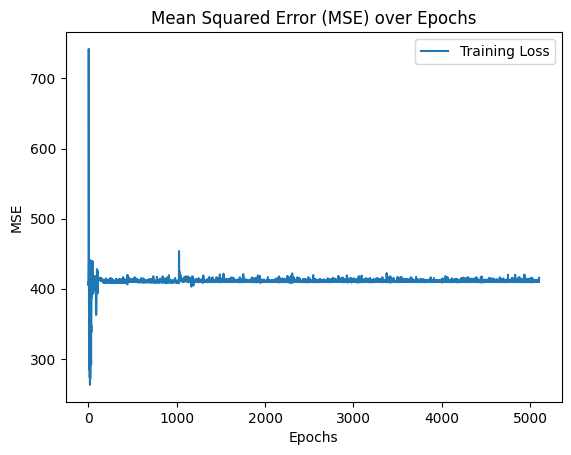

Test MSE: 394.26058985464215
R^2: 0.06878423720703275


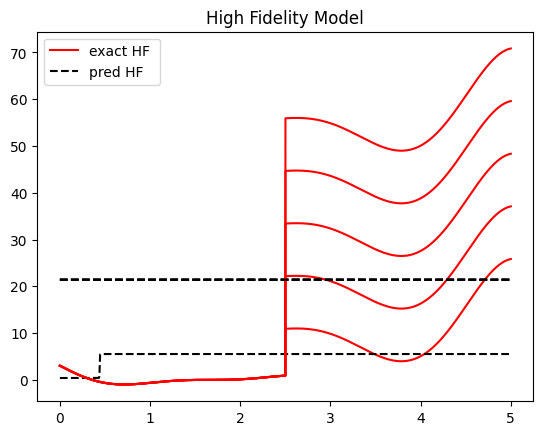

In [4]:
# parameters of the Neural Network
bestHF_params = {'lr' : 0.0255, 
                 'kernel_init' : 'glorot_uniform', 
                 'opt' : 'Adam'}

# inputs for the definition of a Single level Neural Network
# the definition is very similar to its LF counterpart, but with high-fidelity data
definition_HF={
        "network_type": "LF",
        "network_parameters": bestLF_params,
        "dataset_train": data["xhf"],               # high_fidelity data are imported
        "output_train": data["Yhf"],
        "epochs_number": data["NepoHF"],
        "batch_size": data["Nhf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }

# initialization of the neural network
config = NetworkConfig(**definition_HF)
modelHF=NetworkFactory.build_network(config) 

yHF=modelHF.prediction(data["datatest"])
(mse_HF,R2_HF)=modelHF.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

plt.figure()

for val in unique_values:
    mask = data["datatest"][:, 1] == val
    x_values = data["datatest"][mask, 0]
    y_exact = data["modified_highfid"](x_values, val)
    y_pred = yHF[mask]

    plt.plot(x_values, y_exact, 'r', label=f'exact HF ' if val == unique_values[0] else "")
    plt.plot(x_values, y_pred, 'k--', label=f'pred HF ' if val == unique_values[0] else "")

 
plt.legend()
plt.title('High Fidelity Model')

plt.show()

# "2-step" Multi-fidelity Neural Network

The exploitation of 2 connected neural networks can improve our ability to approximate a target function 

The function training took 30.734989 seconds.


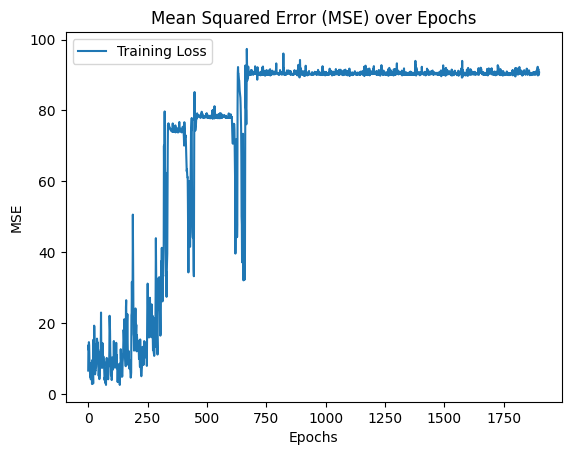

The function training took 65.867331 seconds.


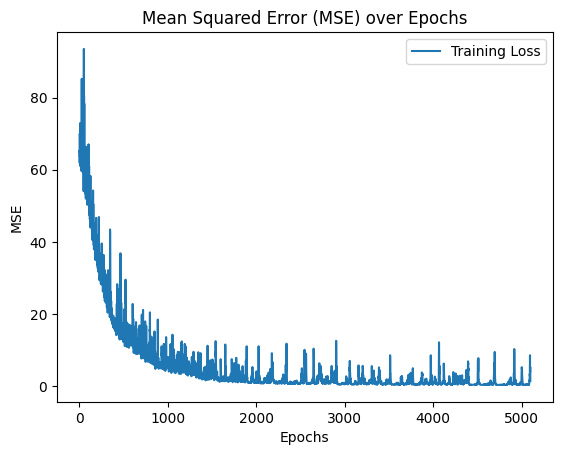

Test MSE: 9.487467773663324
R^2: 0.9775912689039428


NameError: name 'unique_values' is not defined

<Figure size 640x480 with 0 Axes>

In [3]:
### 2 steps NEURAL NETWORK ###

# parameters for the LF (first) Neural Network
bestLF_params = {
    'lr': 0.0255, 
    'kernel_init': 'glorot_uniform', 
    'opt': 'Adam'
}

# parameters for the HF (second) Neural Network
best_params = {
    'kernel_init': 'uniform', 
    'l2weight': 0.00010018625799978436, 
    'lr': 0.07093837044166487, 
    'nodes': 74, 
    'opt': 'Adamax'
}


# Collection of elements of both networks in a ordered list
params = [bestLF_params, best_params]
N = [data["NepoLF"], data["NepoHF"]]
n = [data["Nlf"], data["Nhf"]]
# names of the networks 
names = ['LF', 'HF']


# collection of the parameters for the "2-step Neural Network"
# you can notice that the definition is very similar to the one of a classical neural network, but with a list of elements, which must be in the right element following the sequence of the networks
# Here a 2 levels case is shown, but this can be generalized to any number of levels after providing the definition of the structure of the NNs in the support file 
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "network_parameters": params,
    "dataset_train": [data["xlf"], data["xhf"]],
    "output_train": [data["Ylf"], data["Yhf"]],
    "epochs_number": N,
    "batch_size": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}



# initialization of the neural network
config = NetworkConfig(**definition_2steps)
final_model=NetworkFactory.build_network(config) 

# analysis of the results
y_test=final_model.prediction(data["datatest"])
(mse_MF,R_MF)=final_model.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))



# plot of the result. It is possible to notice that this system is showing stronger performance with respect to NNs both trained and tested on Low and high fidelity data
plt.figure()
for val in unique_values:
    mask = data["datatest"][:, 1] == val
    x_values = data["datatest"][mask, 0]
    y_exact = data["modified_highfid"](data["datatest"][mask,0],data["datatest"][mask,1])
    y_pred = y_test[mask]

    plt.plot(x_values, y_exact, 'r', label=f'exact HF ' if val == unique_values[0] else "")
    plt.plot(x_values, y_pred, 'k--', label=f'pred HF ' if val == unique_values[0] else "")

 
plt.legend()
plt.title('Multi-Fidelity Model')
plt.show()


# Bayesian Inverse Problem 

In this part, given a dataset with some observations related to the parameter we want to estimate, an estimate of this parameter is given through a Bayesian approach 

In [4]:
mean_prior =np.array([7.5])
cov_prior=np.diag([ 0.1])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (49,51)
parameters =np.array([15])
sigma_bounds = ( .09,.11)
rwmh_scaling_bounds =  (0.09,.11)
rwmh_cov = 1
rwmh_adaptive = True
iterations = 500
burnin = 50
n_chains = 2
algo = "MH_tiny" # Metropolis-Hastings of tinyDA library

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
module_directory = os.path.abspath(os.path.join('..', 'utils'))
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

BIP=BayesianInverseProblem_NN(algorithm_name=algo,forward_NN=final_model)

BIP.hpo(inputs_HF=data["xhf"], 
    domain_bounds=(0.,5.),
    mean_prior=mean_prior, 
    cov_prior=cov_prior, 
    output_HF=data["Yhf"], 
    sigma_noise=sigma_noise_bounds, 
    number_data=n_data_bounds,
    real_parameters=parameters, 
    sigma=sigma_bounds,
    rwmh_scaling=rwmh_scaling_bounds, 
    rwmh_covariance=rwmh_cov, 
    rwmh_adaptive=rwmh_adaptive, 
    iterations=iterations, 
    burn_in=burnin, 
    n_chains= n_chains, 
    levels=1,  
    force_sequential=True,
    initial_points_optimizer=3,
    iterations_optimizer=10,
    subsampling_rate=1
    )

HPO with  MH_tiny
Executing specific HPO for MH_tiny with Library TinyDA
|   iter    |  target   |  n_data   | rwmh_s... |   sigma   | sigma_... |
-------------------------------------------------------------------------
Sampling chain 1/2


Running chain, α = 0.50:   0%|          | 1/500 [00:00<01:11,  7.01it/s]c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.04: 100%|██████████| 500/500 [01:02<00:00,  8.03it/s]


Sampling chain 2/2


Running chain, α = 0.08: 100%|██████████| 500/500 [01:21<00:00,  6.15it/s]


The function param_inverse took 154.453068 seconds.
| 1         | -0.0532   | 49.75     | 0.109     | 0.1046    | 0.3997    |


KeyboardInterrupt: 

### with the best found parameters we can rerun a final estimation

HPO with MH_tiny
Executing specific run for MH_tiny with Library TinyDA
Sampling chain 1/2


Running chain, α = 0.33:   0%|          | 2/500 [00:00<01:05,  7.64it/s]c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.23: 100%|██████████| 500/500 [01:02<00:00,  8.04it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 500/500 [01:00<00:00,  8.24it/s]


The difference between estimated values [2.789]



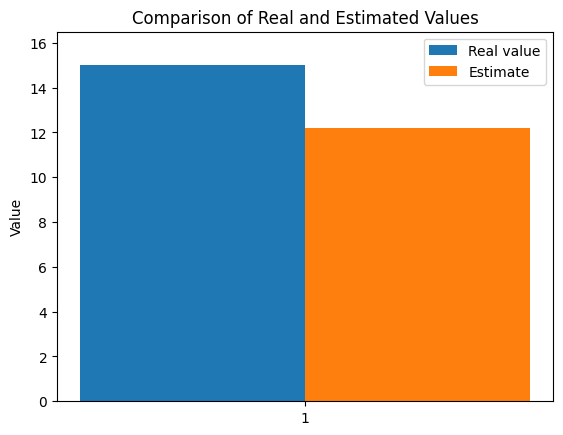

The function param_inverse took 125.805485 seconds.


In [11]:
BIP.run(inputs_HF=data["xhf"], 
    domain_bounds=(0.,7.),
    mean_prior=mean_prior, 
    cov_prior=cov_prior, 
    output_HF=data["Yhf"], 
    real_parameters=parameters, 
    rwmh_adaptive=rwmh_adaptive, 
    iterations=iterations, 
    burn_in=burnin, 
    n_chains= n_chains, 
    levels=1,  
    force_sequential=True,
    number_data=50, 
    sigma=0.1,                          
    rwmh_scaling=0.1, 
    rwmh_covariance=0.1, 
    sigma_noise=0.25
)